In [1]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

print("Mulai scraping...")

ipusnas_reviews = reviews_all(
    'mam.reader.ipusnas',
    sleep_milliseconds=0,
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

print("Scraping selesai!")

# Convert ke DataFrame
df = pd.DataFrame(ipusnas_reviews)

print("Jumlah review yang berhasil diambil:", len(df))

# Simpan ke CSV
df.to_csv("ipusnas_reviews_all.csv", index=False)

df.head()

Mulai scraping...
Scraping selesai!
Jumlah review yang berhasil diambil: 20258


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a2226ba3-3a6c-405e-9a5b-86eaa3be2e21,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kacau bangt ni apk, kaya cuma di kasih harapan...",1,0,None,2026-03-23 20:28:14,None,NaT,None
1,690daab6-5fa6-4de1-9d3e-8a15657064a2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi literasi kok eror niat ga sih pemerin...,1,0,None,2026-03-23 18:20:19,None,NaT,None
2,630a2cd9-2a9b-483b-a7d7-0afe9a874ac9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi gajelas, sering eror",1,0,2.1.2,2026-03-23 17:34:26,None,NaT,2.1.2
3,4b6a4576-356d-4787-99d3-59be5620d021,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"udah ngelist yang mau dibaca, ternyata aplikas...",1,0,2.1.2,2026-03-23 16:14:36,None,NaT,2.1.2
4,60e43d04-c0f4-4a87-b20b-a457dbfd2af4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi yang paling saya suka, sayangnya deve...",1,0,2.1.2,2026-03-23 15:10:06,None,NaT,2.1.2


In [3]:
df.shape

(20258, 11)

In [4]:
df.describe()

,score,thumbsUpCount,at,repliedAt
count,20258.000000,20258.000000,20258,13128
mean,2.837348,1.887847,2022-05-16 12:56:27.749531136,2020-10-06 20:04:44.260816640
min,1.000000,0.000000,2016-08-16 14:28:20,2016-12-02 08:32:38
25%,1.000000,0.000000,2019-11-26 11:19:02,2019-05-24 08:14:07.750000128
50%,3.000000,0.000000,2021-11-23 14:44:14.500000,2020-07-26 13:34:40
75%,5.000000,0.000000,2025-01-19 07:03:05,2021-11-25 11:24:46.249999872
max,5.000000,2284.000000,2026-03-23 20:28:14,2025-09-09 14:50:16
std,1.658704,24.737228,NaN,NaN


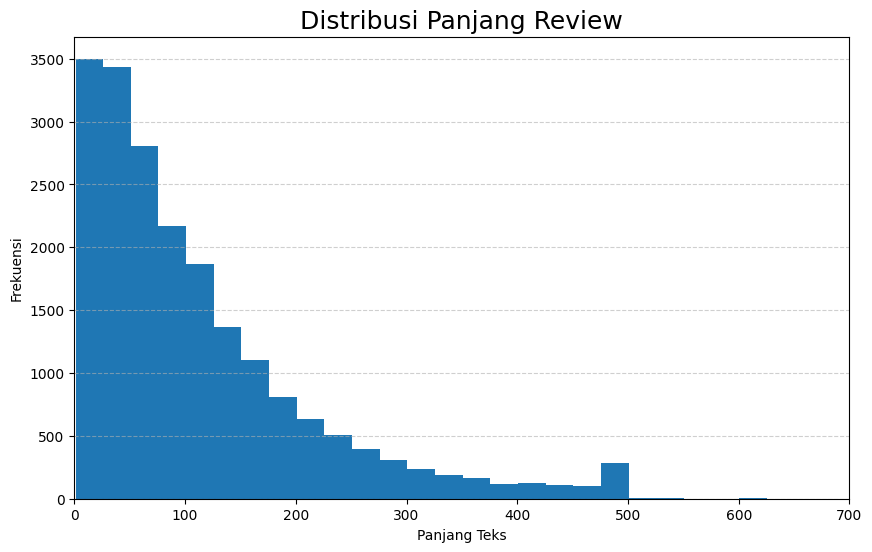

In [16]:
import matplotlib.pyplot as plt

text_column = 'content' 

df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(10,6))
plt.hist(df['text_length'], bins=50)

plt.title("Distribusi Panjang Review", fontsize=18)
plt.xlabel("Panjang Teks")
plt.ylabel("Frekuensi")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.xlim(0, 700)

plt.show()

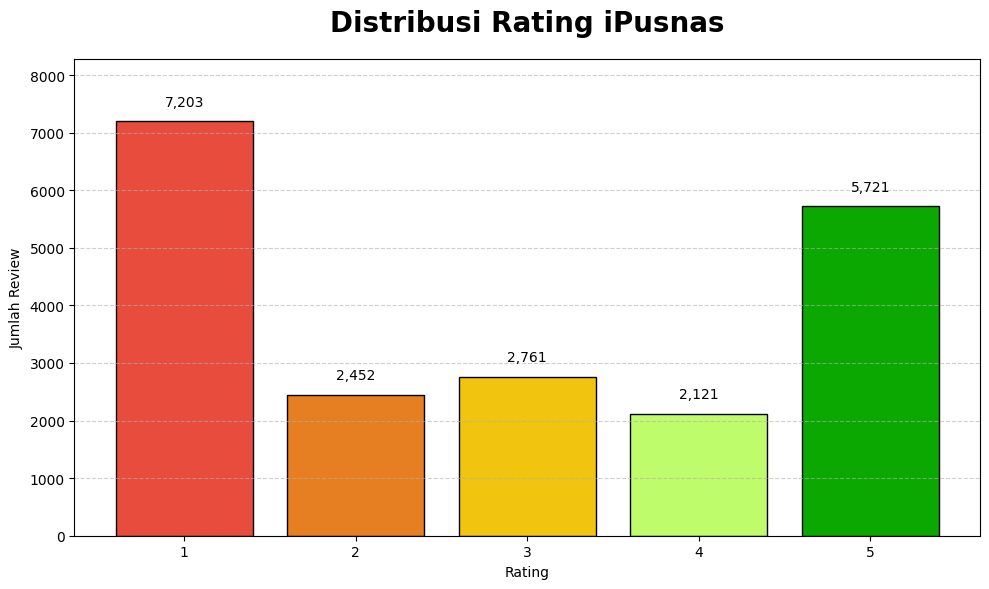

In [10]:
df_count = df['score'].value_counts().sort_index()

score_colors = {
    1: '#e74c3c',
    2: '#e67e22',
    3: '#f1c40f',
    4: '#bffc6b',
    5: '#0aa800',
}

colors = [score_colors[score] for score in df_count.index]

plt.figure(figsize=(10, 6))

bars = plt.bar(df_count.index, df_count.values, color=colors, edgecolor='black')

plt.title('Distribusi Rating iPusnas', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [11]:
from collections import Counter

all_text = ' '.join(df['content'].dropna().astype(str)).lower()
words = all_text.split()

word_counts = Counter(words)
common_words = word_counts.most_common(20)

word_freq_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
display(word_freq_df)

,Word,Frequency
0,bisa,8691
1,buku,6944
2,saya,5717
3,di,5394
4,aplikasi,4998
5,dan,4746
6,tidak,4552
7,yang,4262
8,ini,4123
9,ada,3221


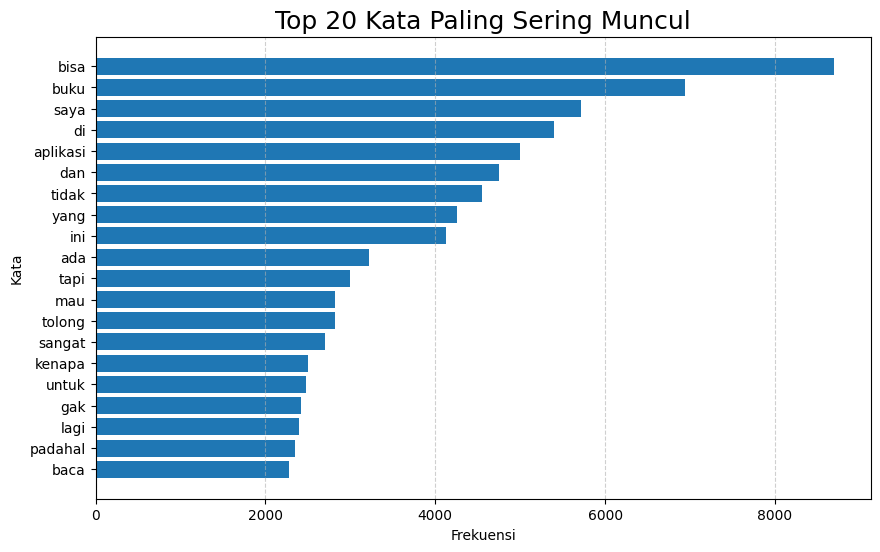

In [12]:
plt.figure(figsize=(10,6))

plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])

plt.title("Top 20 Kata Paling Sering Muncul", fontsize=18)
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

In [13]:
print("Jumlah data:", len(df))
print("Rata-rata panjang review:", df['text_length'].mean())
print("Review terpanjang:", df['text_length'].max())
print("Review terpendek:", df['text_length'].min())

Jumlah data: 20258
Rata-rata panjang review: 111.59704807977096
Review terpanjang: 1250
Review terpendek: 1
